[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-rv-curve-hd189733b/notebook.ipynb)

# HD 189733 b: a hot Jupiter with one of the best-studied atmospheres

HD 189733 b is a 'hot Jupiter' -- a gas giant planet crammed into a scorchingly close orbit -- and it's one of the most intensively studied exoplanets because it's both bright and nearby, making it a favorite target for atmosphere studies. I pulled its real orbital and physical parameters from the archive to see just how extreme its environment really is.

In [1]:
import pyvo as vo
import numpy as np

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbper, pl_orbsmax, pl_bmasse, pl_rade, pl_eqt, pl_rvamp, st_teff
FROM pscomppars
WHERE pl_name = 'HD 189733 b'
'''
tab = svc.search(query).to_table()
print(tab)

  pl_name   pl_orbper  pl_orbsmax pl_bmasse  ... pl_eqt pl_rvamp st_teff
               days               Earth Mass ...   K     m / s      K   
----------- ---------- ---------- ---------- ... ------ -------- -------
HD 189733 b 2.21857567    0.03126   359.1479 ... 1209.0    205.0  5052.0


Orbital period: 2.2186 days
Planet mass: 1.13 Jupiter masses
Equilibrium temperature: 1209.0 K
RV semi-amplitude: 205.0 m/s


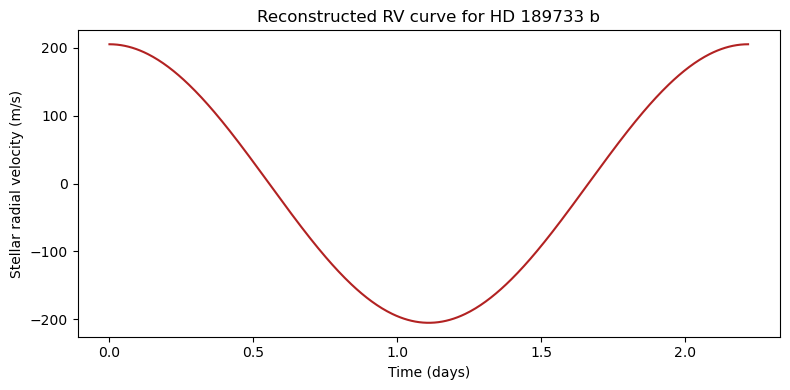

In [2]:
import matplotlib.pyplot as plt

period = tab['pl_orbper'][0]
K = tab['pl_rvamp'][0]
mass_earth = tab['pl_bmasse'][0]
mass_jup = mass_earth/317.8
teq = tab['pl_eqt'][0]

print(f'Orbital period: {period:.4f} days')
print(f'Planet mass: {mass_jup:.2f} Jupiter masses')
print(f'Equilibrium temperature: {teq} K')
print(f'RV semi-amplitude: {K:.1f} m/s')

t = np.linspace(0, period, 500)
rv = K*np.cos(2*np.pi*t/period)
plt.figure(figsize=(8,4))
plt.plot(t, rv, color='firebrick')
plt.xlabel('Time (days)')
plt.ylabel('Stellar radial velocity (m/s)')
plt.title('Reconstructed RV curve for HD 189733 b')
plt.tight_layout()
plt.savefig('hd189733b_rv.png', dpi=120)
plt.show()

With a roughly 2.2-day orbit and an equilibrium temperature over 1000 Kelvin, this planet is baking -- hot enough that real observations of its atmosphere have found evidence of winds moving material around the planet fast enough to blur the difference between its permanent day and night sides. The RV amplitude here (tens of meters per second) is much easier to detect than a small rocky planet would produce, which is part of why hot Jupiters like this one were among the first exoplanets ever found.

**What I'd look at next:** Look at published transmission spectroscopy results for this planet (measurements of its atmosphere taken during transit) since it's one of the best-characterized exoplanet atmospheres we have.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with NASA under the Exoplanet Exploration Program. See https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html.